# Offensive Production Returning, Leaving, Incoming
- based on code originally from the 2024-25 season book ('production_returning.ipynb' to clean and quantify the rosters and stats and 'preseason_production_plots_v1.02.ipynb' for plotting functions)

## Setup and Dependncies

In [100]:
# Dependencies

import os
import sys
import pandas as pd
import numpy as np


# path to TEMP folder
temp_folder = os.path.join(os.getcwd(), '..', 'TEMP')
# Data folder
data_folder = os.path.join(os.getcwd(), '..', 'data', 'player_info')
# Image folder
img_folder = os.path.join(os.getcwd(), '..', 'images')
# Logo folder
logo_folder = os.path.join(os.getcwd(), '..', 'images', 'logos')
# School folder
school_folder = os.path.join(os.getcwd(), '..', 'data', 'school_info')
# Tables folder - Contains pairwise rankings, conference standings, etc.
tables_folder = os.path.join(os.getcwd(), '..', 'data', 'tables')

## Path to 2024-25 stats (csv)
stats_file = os.path.join(data_folder, 'NCAA_stats_2024-25.csv')
stats_2024_df = pd.read_csv(stats_file)


################################################################################
roster_file = os.path.join(data_folder, 'EP_master_roster_v0.2_9-14.csv') # PATH TO THE ROSTER FILE -  Currently Using Elite Prospects Scrape
roster_file = os.path.join(data_folder, 'roster_2025_26_first_run_v4_ex20250827.csv') # PATH TO ROSTER FILE FROM CHN
roster_2025_df = pd.read_csv(roster_file) # read as dataframe

# Path to school info table (csv)
school_info_file = os.path.join(school_folder, 'arena_school_info.csv')
school_info_df = pd.read_csv(school_info_file)

In [101]:
## Display head of each table to check the load
# print(roster_2025_df.head())
# print(stats_2024_df.head())
# print(school_info_df.head())

In [102]:
roster_2025_df.head(35)

# Print roster length
print(f"Roster length: {len(roster_2025_df)}")

### HOTFIX - REMOVE GOALIES
roster_2025_df = roster_2025_df[roster_2025_df['Position'] != 'Goaltenders']

# Print updated roster length
print(f"Updated roster length: {len(roster_2025_df)}")

Roster length: 2046
Updated roster length: 1826


## Dictionaries and Constants
- Conference Membership Updated to Remove American Intl who dropped their program after 2024-25 season

In [103]:
## Conference Membership

atlantic = ['Air Force', 'Army', 'Bentley', 'Canisius', 'Holy Cross', 'Mercyhurst', 
            'Niagara', 'RIT', 'Robert Morris', 'Sacred Heart']

big_ten = ['Michigan', 'Michigan State', 'Minnesota', 'Notre Dame', 'Ohio State', 'Penn State', 'Wisconsin']

ccha = ['Augustana', 'Bemidji State', 'Bowling Green', 'Ferris State', 'Lake Superior', 'Michigan Tech', 
        'Minnesota State', 'Northern Michigan', 'St Thomas']

ecac = ['Brown', 'Clarkson', 'Colgate', 'Cornell', 'Dartmouth', 'Harvard', 'Princeton', 'Quinnipiac',
        'Rensselaer', 'St Lawrence', 'Union', 'Yale']

hockey_east = ['Boston College', 'Boston University', 'Connecticut', 'Maine', 'Massachusetts', 'Mass Lowell',
                'Merrimack', 'New Hampshire', 'Northeastern', 'Providence', 'Vermont']

nchc = ['Arizona State', 'Colorado College', 'Denver', 'Miami', 'Minnesota Duluth', 'North Dakota', 'Omaha', 'St Cloud State',
        'Western Michigan']

independents = ['Alaska Anchorage', 'Alaska', 'Lindenwood', 'Long Island', 'Stonehill']

# Create a dictionary of {Team: logo_abv} for each team with .png added to the end
logo_mapping = {}

for index, row in school_info_df.iterrows():
    logo_mapping[row['Team']] = row['logo_abv'] + '.png'

# print(logo_mapping)

#### Style and Colors

In [104]:
color_scheme = {
    'Returning Goals': '#2E8B57',  # Dark Green
    'Returning Assists': '#90EE90',  # Light Green
    'Departed Goals': '#B22222',  # Dark Red
    'Departed Assists': '#FF7F7F',  # Light Red
    'New Goals': '#1E90FF',  # Dark Blue
    'New Assists': '#87CEFA'  # Light Blue
}


figure_size = (10, 10)


## FONT SETTINGS
font_properties = {'fontsize': 24, 'fontweight': 'bold', 'family': 'Verdana'}  # You can change 'serif' to any font family you prefer


### Data Cleaning and Modifications
- Remove Trouble character from Team Names


In [105]:


######
# Remove - from CHN Team names
stats_2024_df['Team'] = stats_2024_df['Team'].str.replace('-', ' ')
# roster_2024_df['Team'] = roster_2024_df['Team'].str.replace('-', ' ')
stats_2024_df['Team'] = stats_2024_df['Team'].str.replace('.', '')
stats_2024_df['Team'] = stats_2024_df['Team'].str.replace("'", '')
# Lower Case columns
stats_2024_df.columns = stats_2024_df.columns.str.lower()

# stats_2024_df.head()

#### Rename Columns in Roster File for easier merging
# Renam Current Team to Team
roster_2025_df = roster_2025_df.rename(columns={'Current Team': 'Team'})

# Create ne column called CLean_Player by merging First and Last Name
roster_2025_df['Clean_Player'] = roster_2025_df['First_Name'] + ' ' + roster_2025_df['Last_Name']
# Strip leading and trailing spaces
roster_2025_df['Clean_Player'] = roster_2025_df['Clean_Player'].str.strip()

# Lower Case columns
roster_2025_df.columns = roster_2025_df.columns.str.lower()

# roster_2025_df.head(35)

## Indentify Transfers

### CHN Data
- Compare 2025 roster to 2024 year end stats and flag players as returning vs departed
- Output 'transfers' dataframe with player, team 2024 and team 2025

In [106]:
# Step 1: Identify players that appear on different teams in the 2023 stats compared to the 2024 roster

# Merge the dataframes on the player name ('Clean_Player') to compare teams
transfer_df = pd.merge(stats_2024_df[['clean_player', 'team']], roster_2025_df[['clean_player', 'team']], on='clean_player', suffixes=('_2024', '_2025'))

# Filter for players who have a different team in 2023 compared to 2024
transfers = transfer_df[transfer_df['team_2024'] != transfer_df['team_2025']]
# # Rename Clean_Player to Player
transfers = transfers.rename(columns={'clean_player': 'player'})


# Reindex and save as csv to TEMP folder
transfers = transfers.reset_index(drop=True)
transfers.to_csv(os.path.join(temp_folder, 'transfers_2025.csv'))

# Create a count of transfers in per team
transfer_counts = transfers['team_2024'].value_counts().reset_index()
transfer_counts.columns = ['team', 'transfer_count']

## Print report on transfers


transfers.head()
# transfer_counts.head(10)


,player,team_2024,team_2025
0,Adam Eisele,Minnesota State,Ohio State
1,Aiden Dubinsky,Minnesota Duluth,Wisconsin
2,Alex Gaffney,Harvard,St Thomas
3,Alfred Lindberg,American Intl,RPI
4,Anthony Menghini,Minnesota Duluth,North Dakota


## Other Transfer Data - The Rink Live
- Taken from the College Hockey News
- Last Season I used data from the Rink Live - will need to adjust code or table format to match last years

In [107]:
transfer_table_path = os.path.join(data_folder, 'chn_transfer_portal_data_table_2.csv')
transfer_table = pd.read_csv(transfer_table_path)

# transfer_table.head()

In [108]:
### Trandsformation of CHN Transfer Table
print(f"Number of players before removing goalies: {len(transfer_table)}")
# Filter our Goalies as they are not relevant to offensive production
transfer_table = transfer_table[transfer_table['Pos.'] != 'G']
transfer_table = transfer_table.reset_index(drop=True)

# Check to see how many goalies were removed
print(f"Number of players after removing goalies: {len(transfer_table)}")



Number of players before removing goalies: 292
Number of players after removing goalies: 248


In [109]:
#### Explode the States column into multiple columns (Goals, Assists, Points, Plus/Minus)
transfer_table[['Goals', 'Assists', 'Points', '+/-']] = transfer_table['Stats'].str.extract(r'(\d+)[-–—](\d+)[-–—](\d+),\s*([+-]?\d+)').astype(int).fillna(0)

# Transform Column Names
# Drop any . in column names
transfer_table.columns = transfer_table.columns.str.replace('.', '', regex=False).str.strip()
# Camel Case column names
transfer_table.columns = transfer_table.columns.str.replace(' ', '_', regex=False).str.title()
# Rename Columns to matach the transfer table naming convention
transfer_table = transfer_table.rename(columns={
    'New_Team': 'team_2025',
    'Old_Team': 'team_2024',
})

# Lower Case columns
transfer_table.columns = transfer_table.columns.str.lower()

transfer_table.head()

,player,yr,pos,team_2024,team_2025,stats,goals,assists,points,+/-
0,Logan Morrell,Fr,F,Michigan Tech,Arizona State,"11-10—21, +5",11,10,21,5
1,John Waldron,Jr,F,Miami,Arizona State,"4-16—20, -19",4,16,20,-19
2,Noah Powell,Fr,F,Ohio State,Arizona State,"2-3—5, 0",2,3,5,0
3,Ryan Alexander,Jr,F,Arizona State,Colorado College,"3-5—8, +11",3,5,8,11
4,Seth Constance,Fr,D,Northeastern,Colorado College,"0-1—1, -4",0,1,1,-4


#### Merge CHN Transfer Table data into existing 'transfers' df

In [110]:
# Merge my transfer table with CHN Table data
merged_df = transfers.merge(transfer_table, on=['player', 'team_2025'], how='outer', indicator=True)

# Identify players that are in my transfer table but not in CHN Table data
only_in_my_transfers = merged_df[merged_df['_merge'] == 'left_only']

# Identify players that are in CHN Table data but not in my transfer table
only_in_rink_live = merged_df[merged_df['_merge'] == 'right_only']

# Save the results to CSV files
only_in_my_transfers.to_csv(os.path.join(temp_folder, 'only_in_my_transfers.csv'), index=False)
only_in_rink_live.to_csv(os.path.join(temp_folder, 'only_in_rink_live.csv'), index=False)

# Print a summary of the results
print(f"Total transfers in my data: {len(transfers)}")
print(f"Total transfers in CHN Table data: {len(transfer_table)}")
print(f"Players only in my transfers data: {len(only_in_my_transfers)}")
print(f"Players only in CHN Table data: {len(only_in_rink_live)}")


Total transfers in my data: 157
Total transfers in CHN Table data: 248
Players only in my transfers data: 41
Players only in CHN Table data: 132


In [111]:
#### Quantify how much production is transferring into each team
## Rename clean_player to player in stats_2024_df for merging
stats_2024_df = stats_2024_df.rename(columns={'clean_player': 'player'})

# Merge the transfer list with the stats_2024_df to bring in the player stats
transfer_stats = transfers.merge(stats_2024_df, on='player', how='left')

transfer_stats.head()

## Check A Team 
# # Michigan State team_2025
# michigan_state_transfers = transfer_stats[transfer_stats['team_2025'] == 'Michigan State']
# michigan_state_transfers.head()

,player,team_2024,team_2025,team,g,a,pts,plus_minus,sh,toi_sec,pim,fow,fol,games_played,fo%,toi
0,Adam Eisele,Minnesota State,Ohio State,Minnesota State,13,13,26,23,87,37573.0,49,337.0,278.0,37,54.796748,10:26:13
1,Aiden Dubinsky,Minnesota Duluth,Wisconsin,Minnesota Duluth,4,10,14,-2,46,46129.0,20,0.0,0.0,36,NaN,12:48:49
2,Alex Gaffney,Harvard,St Thomas,Harvard,0,0,0,0,3,2806.0,0,0.0,1.0,4,0.000000,00:46:46
3,Alfred Lindberg,American Intl,RPI,American Intl,7,4,11,-17,77,31122.0,4,232.0,214.0,33,52.017937,08:38:42
4,Anthony Menghini,Minnesota Duluth,North Dakota,Minnesota Duluth,12,7,19,6,107,33175.0,15,1.0,2.0,35,33.333333,09:12:55


In [112]:
# Rename clean_player to player in roster_2025_df for merging
roster_2025_df = roster_2025_df.rename(columns={'clean_player': 'player'})

# Step 1: Match the players from 2024 stats to 2025 roster based on 'Clean_Player'
# We'll merge the two DataFrames on 'Clean_Player' to identify returning players
merged_df = pd.merge(stats_2024_df, roster_2025_df[['player', 'team']], on='player', how='left', suffixes=('_2024', '_2025'))

# Step 2: Classify players as "Returning" or "Departed"
merged_df['Status'] = merged_df['team_2025'].notna().map({True: 'Returning', False: 'Departed'})

# HOTFIX TO DEAL WITH TRANSFERRED PLAYERS
# If Team_2024 is not equal to Team_2025, then the player transferred - set Status to 'Departed'
merged_df.loc[merged_df['team_2024'] != merged_df['team_2025'], 'Status'] = 'Departed'

# Step 3: Calculate total production for each group (Returning and Departed) by team
team_production = merged_df.groupby(['team_2024', 'Status']).agg({
    'g': 'sum',
    'a': 'sum',
    'sh': 'sum',
    'pim': 'sum',
    'pts': 'sum',
    'games_played': 'sum'
}).reset_index()

# Step 4: Pivot the table to make "Returning" and "Departed" production easy to compare for each team
team_production_pivot = team_production.pivot(index='team_2024', columns='Status', values=['g', 'a', 'pts', 'sh', 'pim', 'games_played']).fillna(0)

# Flatten the MultiIndex for clarity
team_production_pivot.columns = ['_'.join(col).strip() for col in team_production_pivot.columns.values]

# Copy team_2023 values to new column called Team
team_production_pivot['Team'] = team_production_pivot.index



team_production_pivot.head()

,g_Departed,g_Returning,a_Departed,a_Returning,pts_Departed,pts_Returning,sh_Departed,sh_Returning,pim_Departed,pim_Returning,games_played_Departed,games_played_Returning,Team
team_2024,,,,,,,,,,,,,
Air Force,29.0,57.0,37.0,114.0,66.0,171.0,299.0,991.0,87.0,249.0,205.0,599.0,Air Force
Alaska,55.0,24.0,73.0,56.0,128.0,80.0,493.0,431.0,186.0,192.0,325.0,349.0,Alaska
Alaska Anchorage,26.0,49.0,39.0,81.0,65.0,130.0,296.0,513.0,162.0,152.0,280.0,406.0,Alaska Anchorage
American Intl,92.0,0.0,163.0,0.0,255.0,0.0,1121.0,0.0,338.0,0.0,771.0,0.0,American Intl
Arizona State,87.0,49.0,144.0,95.0,231.0,144.0,688.0,524.0,164.0,102.0,435.0,307.0,Arizona State


In [113]:
## Merge in the transfer stats to quantify incoming production

# Step 1: Calculate total production for incoming transfers
incoming_transfer_stats = transfer_stats.groupby('team_2025').agg({
    'g': 'sum',
    'a': 'sum',
    'sh': 'sum',
    'pim': 'sum',
    'pts': 'sum',
    'games_played': 'sum'
}).reset_index()

# Step 2: Rename the columns for clarity
incoming_transfer_stats = incoming_transfer_stats.rename(columns={
    'team_2025': 'Team',
    'g': 'incoming_g',
    'a': 'incoming_a',
    'sh': 'incoming_sh',
    'pim': 'incoming_pim',
    'pts': 'incoming_pts',
    'games_played': 'incoming_games_played'
})

# Step 3: Merge the incoming transfer stats with the team production pivot
final_team_production = team_production_pivot.merge(incoming_transfer_stats, on='Team', how='left').fillna(0)

# # Step 4: Calculate total production for each team
# final_team_production['total_g'] = final_team_production['incoming_g'] + final_team_production['g_Returning']

# # Output to TEMP folder
final_team_production.to_csv(os.path.join(temp_folder, 'final_team_production_2025_v1.01.csv'), index=False)



## Visualization / Chart Creation

### Dependencies

In [114]:
# Dependencies
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerBase
from PIL import Image
import time

## Setup
# get and store date as string ex. "Spetember 1, 2023"
date = time.strftime("%B %d, %Y")


# Path to Final Pairwise Ranking From Last Season (2023-24) 
## For Use in sorting charts later potentially
pairwise_file = os.path.join(tables_folder, 'final_pairwise_202425.csv')
pairwise_df = pd.read_csv(pairwise_file) # Load DF
## Clean up names in Pairwise DF for matching
pairwise_df['Team'] = pairwise_df['Team'].str.replace('.', '')
pairwise_df['Team'] = pairwise_df['Team'].str.replace('-', ' ')
# pairwise_df.head()


## Rename the final team production file dataframe to df to reuse code from last year's book
df = final_team_production.copy()


### Plotting Functions and Sub Functions

In [115]:
# Fix the add_logos_to_plot function to avoid KeyError
def add_logos_to_plot(data_df, team_names, logo_mapping, logo_folder, ax, bar_width):
    for i, team in enumerate(team_names):
        logo_file = logo_mapping.get(team, "")
        if logo_file:
            logo_path = os.path.join(logo_folder, logo_file)
            try:
                logo_img = plt.imread(logo_path)
                imagebox = OffsetImage(logo_img, zoom=0.175)  # Adjust zoom as needed
                # Adjust the positioning of logos below the x-axis
                ab = AnnotationBbox(imagebox, (i + bar_width / 2, -0.055), xycoords=('data', 'axes fraction'), frameon=False)
                ax.add_artist(ab)
            except Exception as e:
                print(f"Error adding logo for {team}: {e}")

## Plot

C:\Users\jbanc\AppData\Local\Temp\ipykernel_12828\1185695133.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Rk'] = filtered_df['Team'].map(pairwise_df.set_index('Team')['Rk'])


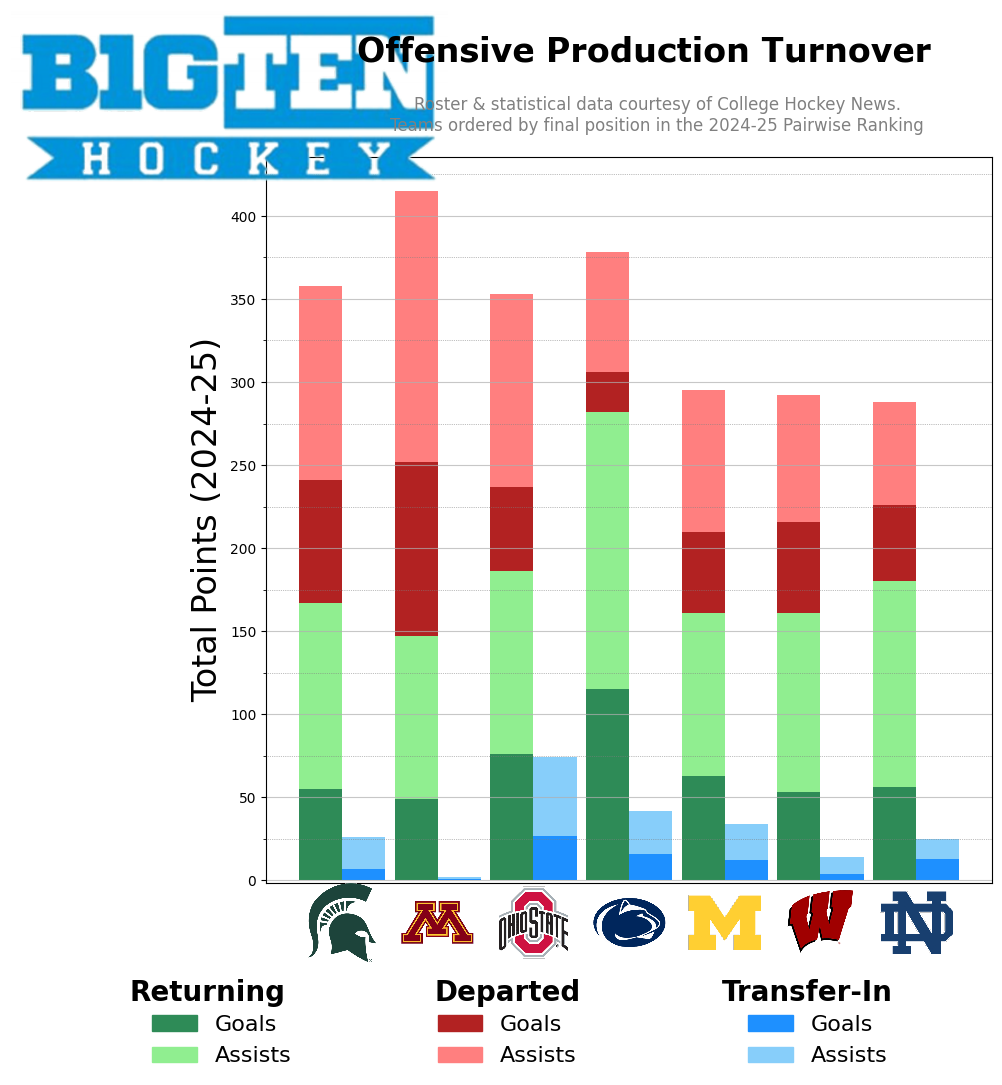

C:\Users\jbanc\AppData\Local\Temp\ipykernel_12828\1185695133.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Rk'] = filtered_df['Team'].map(pairwise_df.set_index('Team')['Rk'])


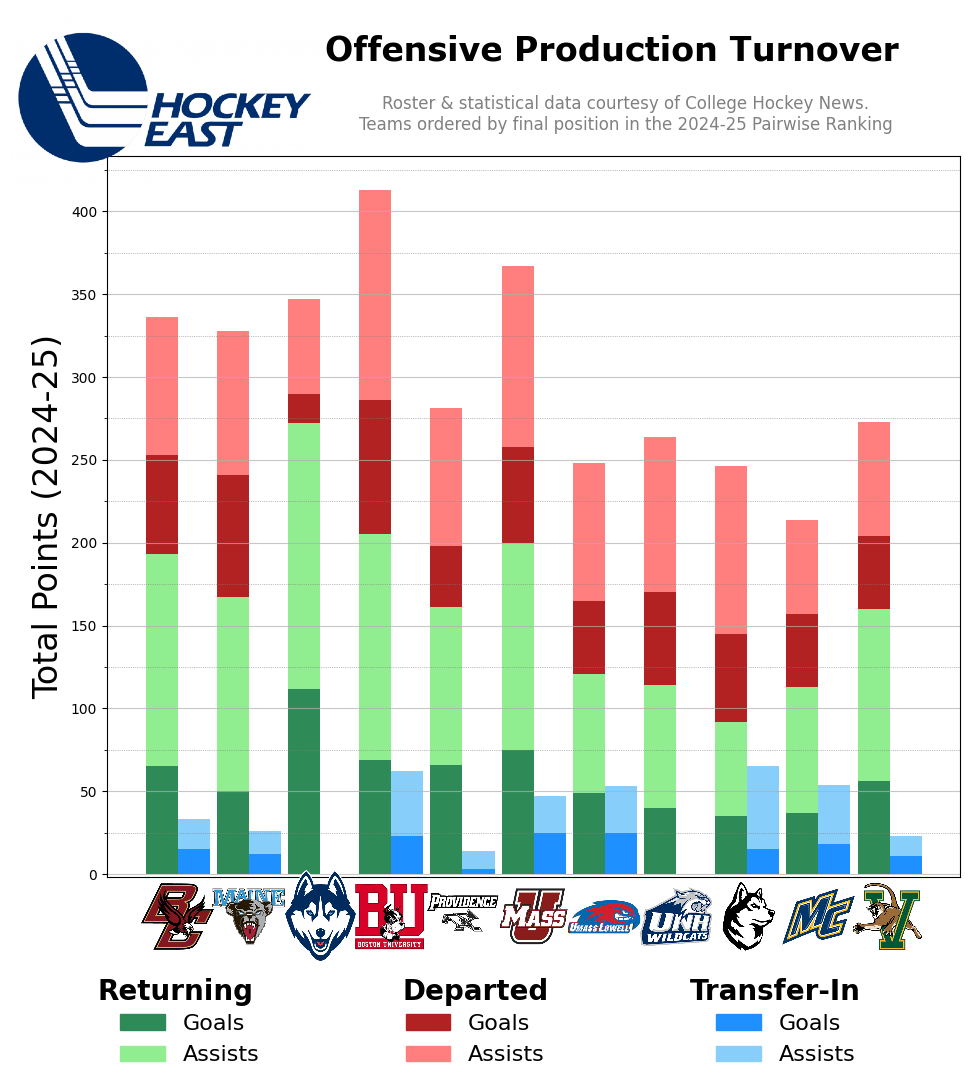

C:\Users\jbanc\AppData\Local\Temp\ipykernel_12828\1185695133.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Rk'] = filtered_df['Team'].map(pairwise_df.set_index('Team')['Rk'])


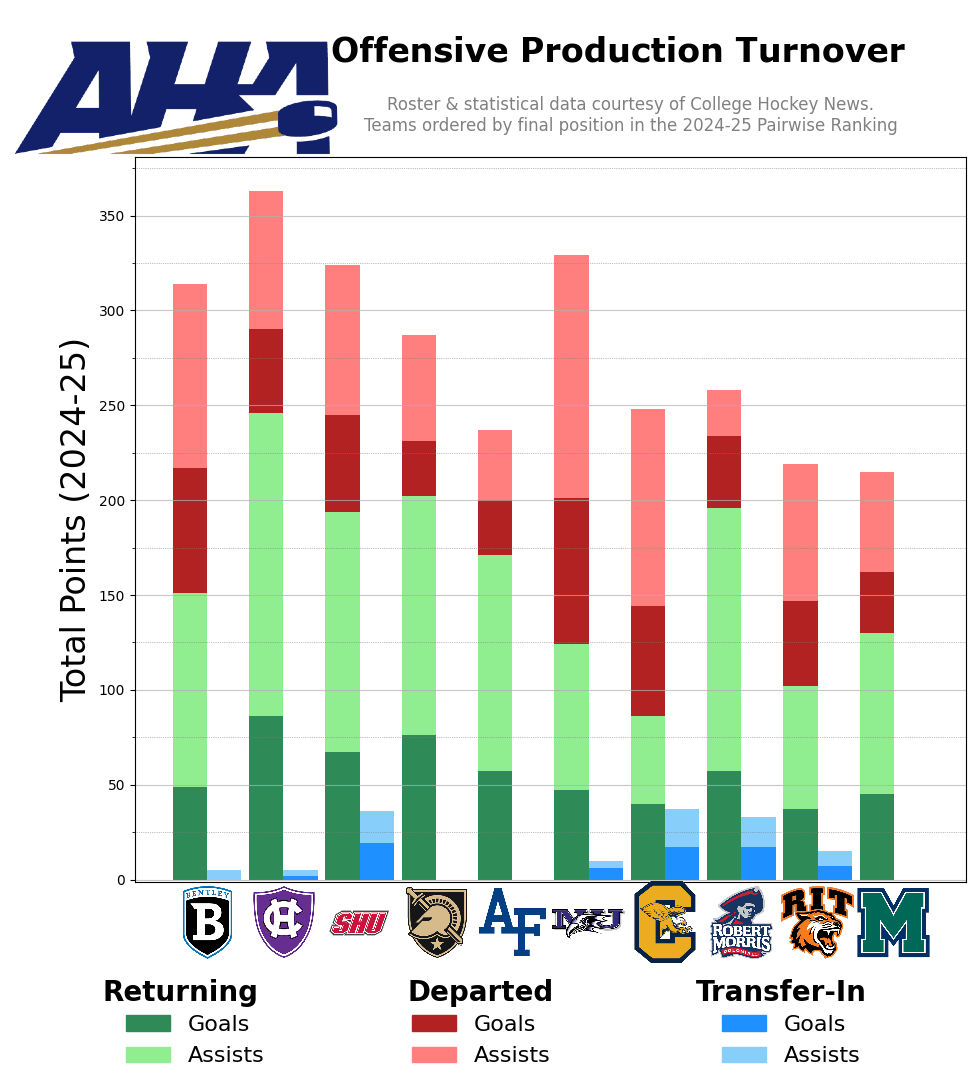

In [118]:

# Define the function to create the stacked bar chart for each conference
def plot_conference_production(df, conference_teams, conference_name, logo_mapping, logo_folder, ax=None, conference_logo=None):
    """
    Function to create a stacked bar chart for team production in a specific conference.

    Parameters:
    - df: DataFrame containing team production data.
    - conference_teams: List of teams in the conference.
    - conference_name: Name of the conference.
    - logo_mapping: Dictionary mapping teams to their logo filenames.
    - logo_folder: Path to the folder containing the logos.
    - ax: Optional Matplotlib axis object for plotting. If None, a new plot will be created.
    """
    
    # Filter the dataframe for teams in the conference
    filtered_df = df[df['Team'].isin(conference_teams)]

    # Order the teams based on their RK in the pairwise_df
    filtered_df['Rk'] = filtered_df['Team'].map(pairwise_df.set_index('Team')['Rk'])
    filtered_df = filtered_df.sort_values(by='Rk')
    
    # Check if ax is provided, otherwise create a new figure and axis
    if ax is None:
        fig, ax = plt.subplots(figsize=figure_size)

    # Extract the data needed for the plot
    team_names = filtered_df['Team'].tolist()
    g_returning = filtered_df['g_Returning'].values
    a_returning = filtered_df['a_Returning'].values
    g_departed = filtered_df['g_Departed'].values
    a_departed = filtered_df['a_Departed'].values
    incoming_g = filtered_df['incoming_g'].values
    incoming_a = filtered_df['incoming_a'].values

    # Plot the first stack (returning and departed goals/assists)
    bottom_values = np.zeros(len(team_names))
    bar_width = 0.45  # Adjustable bar width for fine-tuning spacing
    bars1 = ax.bar(team_names, g_returning, bottom=bottom_values, color=color_scheme['Returning Goals'], width=bar_width, label='Goals Returning')
    bottom_values += g_returning
    bars2 = ax.bar(team_names, a_returning, bottom=bottom_values, color=color_scheme['Returning Assists'], width=bar_width, label='Assists Returning')
    bottom_values += a_returning
    bars3 = ax.bar(team_names, g_departed, bottom=bottom_values, color=color_scheme['Departed Goals'], width=bar_width, label='Goals Departed')
    bottom_values += g_departed
    bars4 = ax.bar(team_names, a_departed, bottom=bottom_values, color=color_scheme['Departed Assists'], width=bar_width, label='Assists Departed')

    # Plot the second stack (incoming goals/assists)
    x_positions = np.arange(len(team_names)) + bar_width  # Shift for the second stack
    bars5 = ax.bar(x_positions, incoming_g, color=color_scheme['New Goals'], width=bar_width, label='Goals Incoming')
    bars6 = ax.bar(x_positions, incoming_a, bottom=incoming_g, color=color_scheme['New Assists'], width=bar_width, label='Assists Incoming')

    # Customize the plot
    ## Using Built in Title Function
    # ax.set_title(f'Offensive Production Turnover', 
    #         fontsize=20, weight='bold',
    #         pad = -10,
    #         loc='right')

    ## Using figure.text to place title for more control
    fig.text(0.35, 0.925, 'Offensive Production Turnover', fontdict=font_properties)

        # Add note with data sources underneith title
    fig.text(0.65, 0.855, 
            "Roster & statistical data courtesy of College Hockey News.\nTeams ordered by final position in the 2024-25 Pairwise Ranking", 
            ha='center', fontsize=12, color='gray')

    ax.set_ylabel('Total Points (2024-25)', fontsize=24) #, weight='bold')
    ax.set_xticks(np.arange(len(team_names)) + bar_width / 2)
    ax.set_xticklabels(team_names, fontsize=16)

    # Expand y-axis to allow space for the logos below the bars
    ax.set_ylim(-1.5, ax.get_ylim()[1])  # Adjust this if needed to give more space below

    # Add logos using corrected x-axis positions and team names, passing bar_width
    add_logos_to_plot(filtered_df, team_names, logo_mapping, logo_folder, ax, bar_width)

    # Add and Adjust grid marks
    ax.yaxis.grid(True, linestyle='-', alpha=0.7)
    # add minor grid marks ever 25 points
    ax.yaxis.set_minor_locator(plt.MultipleLocator(25))
    ax.yaxis.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    

    # Remove x-ticks and labels
    ax.set_xticks([])
    ax.set_xticklabels([])

    ############################
    ### ADD CONFERENCE LOGOS
    ############################
        # Data for conferences
    conference_names = ['Atlantic', 'Big Ten', 'CCHA', 'ECAC', 'Hockey East', 'NCHC', 'Independents']

        # Define the standard size for logos (width, height)
    logo_size = (50, 50)  # Adjust the size as needed

    # Add conference logos below the bars as x-tick labels
    conference_logo_mapping = {
        'Atlantic': 'atlantic.png',
        'Big Ten': 'big_ten.png',
        'CCHA': 'ccha.png',
        'ECAC': 'ecac.png',
        'Hockey East': 'hockey_east.png',
        'NCHC': 'nchc.png',
        'Independents': 'independent_scaled.png'
    }
        ## **Add conference logo to the upper-right-hand corner**
    if conference_logo:
        logo_path = os.path.join(logo_folder, 'conference', conference_logo)
        # img = plt.imread(logo_path)
        
        # Set a desired logo size
        # logo_zoom = 0.45  # Adjust this value to control the logo size
                # Get the size of the image and calculate the zoom factor based on the height

        img = Image.open(logo_path)
        img_width, img_height = img.size
        aspect_ratio = img_width / img_height  # Aspect ratio of the image
        
        # Set a fixed height and calculate zoom to preserve aspect ratio
        desired_height = 125  # Adjust the height as needed
        zoom_factor = desired_height / img_height
        
        # Create an OffsetImage for the conference logo
        imagebox = OffsetImage(img, zoom=zoom_factor)
        
        # Add the logo to the upper-left-hand corner of the plot
        ab = AnnotationBbox(imagebox, (0.25, 1.2), xycoords='axes fraction',
                            box_alignment=(1, 1), pad=0.1, frameon=False)
        ax.add_artist(ab)

############################
    ### CUSTOM LEGEND ###
############################
    # Creating the patches for the legend
    legend_patches = [
        mpatches.Patch(color=color_scheme['Returning Goals'], label='Goals'),
        mpatches.Patch(color=color_scheme['Returning Assists'], label='Assists'),
        mpatches.Patch(color=color_scheme['Departed Goals'], label='Goals'),
        mpatches.Patch(color=color_scheme['Departed Assists'], label='Assists'),
        mpatches.Patch(color=color_scheme['New Goals'], label='Goals'),
        mpatches.Patch(color=color_scheme['New Assists'], label='Assists')
    ]

    legend_header_size = 20
    legend_label_font = 16
    
    # Custom grid legend layout using text and patches
    fig.text(0.2, -0.015, 'Returning', fontsize=legend_header_size, weight='bold', ha='center')
    fig.text(0.5, -0.015, 'Departed', fontsize=legend_header_size, weight='bold', ha='center')
    fig.text(0.8, -0.015, 'Transfer-In', fontsize=legend_header_size, weight='bold', ha='center')


    # Adjust legend placement to be centered under the headers
    fig.legend(handles=legend_patches[:2], loc='lower left', bbox_to_anchor=(0.125, -0.1), frameon=False, fontsize=legend_label_font)  # Goals/Assists under 'Returning'
    fig.legend(handles=legend_patches[2:4], loc='lower center', bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=legend_label_font)  # Goals/Assists under 'Departed'
    fig.legend(handles=legend_patches[4:], loc='lower right', bbox_to_anchor=(0.9, -0.1), frameon=False, fontsize=legend_label_font)  # Goals/Assists under 'Transfers-In'

    # sAVE THE oUTPUT iMAGE TO THE tEMP fOLDER
    output_file = os.path.join(temp_folder, f'{conference_name}_production_turnover_v1.png')
    plt.tight_layout()
    plt.savefig(output_file) # , bbox_inches='tight')

    # Display the plot
    
    plt.show()

# # Example call for one of the conferences (e.g., Big Ten)
# plot_conference_production(df, big_ten, "B1G", logo_mapping, logo_folder)

figure_size = (10,10)
plot_conference_production(df, big_ten, "B1G", logo_mapping, logo_folder, conference_logo='big_ten.png')
plot_conference_production(df, hockey_east, "Hockey East", logo_mapping, logo_folder, conference_logo='hockey_east.png')
# plot_conference_production(df, ccha, "CCHA", logo_mapping, logo_folder, conference_logo='ccha.png')
plot_conference_production(df, atlantic, "Atlantic", logo_mapping, logo_folder, conference_logo='atlantic.png')
# plot_conference_production(df, ecac, "ECAC", logo_mapping, logo_folder, conference_logo='ecac.png')
# plot_conference_production(df, nchc, "NCHC", logo_mapping, logo_folder, conference_logo='nchc.png')
# plot_conference_production(df, independents, "Independents", logo_mapping, logo_folder, conference_logo='independent.png')


## Conference to Conference Comparison chart

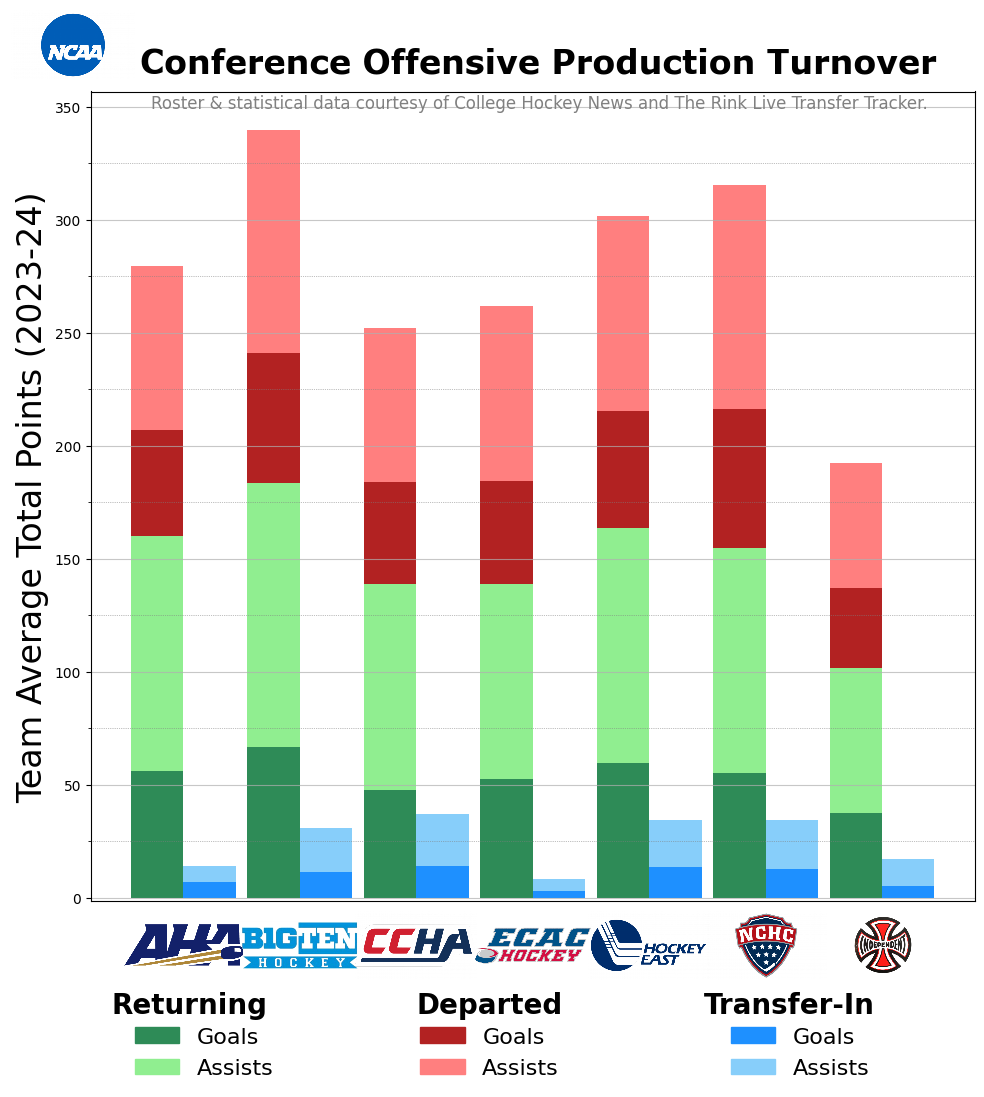

In [117]:
def plot_conference_comparison(df, conferences, logo_mapping, logo_folder, ax=None):
    """
    Function to create a stacked bar chart comparing conference production.
    
    Parameters:
    - df: DataFrame containing team production data.
    - conferences: Dictionary with conference names as keys and lists of team names as values.
    - logo_mapping: Dictionary mapping conferences to their logo filenames.
    - logo_folder: Path to the folder containing the logos.
    - ax: Optional Matplotlib axis object for plotting. If None, a new plot will be created.
    """
    
    # Create a new figure and axis if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figure_size)

    # Initialize lists to store the averaged values for each conference
    conference_names = []
    g_returning_avg = []
    a_returning_avg = []
    g_departed_avg = []
    a_departed_avg = []
    incoming_g_avg = []
    incoming_a_avg = []
    
    # Loop through each conference and calculate the averages
    for conference_name, teams in conferences.items():
        filtered_df = df[df['Team'].isin(teams)]
        conference_names.append(conference_name)
        
        # Calculate the averages for each conference
        g_returning_avg.append(filtered_df['g_Returning'].mean())
        a_returning_avg.append(filtered_df['a_Returning'].mean())
        g_departed_avg.append(filtered_df['g_Departed'].mean())
        a_departed_avg.append(filtered_df['a_Departed'].mean())
        incoming_g_avg.append(filtered_df['incoming_g'].mean())
        incoming_a_avg.append(filtered_df['incoming_a'].mean())

    # Define bar width
    bar_width = 0.45
    
    # Plot the first stack (returning and departed goals/assists)
    bottom_values = np.zeros(len(conference_names))
    bars1 = ax.bar(conference_names, g_returning_avg, bottom=bottom_values, color=color_scheme['Returning Goals'], width=bar_width, label='Goals Returning')
    bottom_values += g_returning_avg
    bars2 = ax.bar(conference_names, a_returning_avg, bottom=bottom_values, color=color_scheme['Returning Assists'], width=bar_width, label='Assists Returning')
    bottom_values += a_returning_avg
    bars3 = ax.bar(conference_names, g_departed_avg, bottom=bottom_values, color=color_scheme['Departed Goals'], width=bar_width, label='Goals Departed')
    bottom_values += g_departed_avg
    bars4 = ax.bar(conference_names, a_departed_avg, bottom=bottom_values, color=color_scheme['Departed Assists'], width=bar_width, label='Assists Departed')

    # Plot the second stack (incoming goals/assists)
    x_positions = np.arange(len(conference_names)) + bar_width  # Shift for the second stack
    bars5 = ax.bar(x_positions, incoming_g_avg, color=color_scheme['New Goals'], width=bar_width, label='Goals Incoming')
    bars6 = ax.bar(x_positions, incoming_a_avg, bottom=incoming_g_avg, color=color_scheme['New Assists'], width=bar_width, label='Assists Incoming')

    # Customize the plot
    fig.text(0.15, 0.925, 'Conference Offensive Production Turnover', fontdict=font_properties)

    # Add note with data sources under the title
    fig.text(0.55, 0.89, 
            "Roster & statistical data courtesy of College Hockey News and The Rink Live Transfer Tracker.", 
            ha='center', fontsize=12, color='gray')

    ax.set_ylabel('Team Average Total Points (2023-24)', fontsize=24)
    ax.set_xticks(np.arange(len(conference_names)) + bar_width / 2)
    ax.set_xticklabels(conference_names, fontsize=16)

    # Expand y-axis to allow space for the logos below the bars
    ax.set_ylim(-1.5, ax.get_ylim()[1])  # Adjust this if needed to give more space below

    # Add conference logos as x-tick labels
    add_logos_to_plot(None, conference_names, logo_mapping, logo_folder, ax, bar_width)
    
    # Add the NCAA logo to the upper-left-hand corner
    ncaa_logo_path = os.path.join(logo_folder, 'ncaa_1.png')
    img = Image.open(ncaa_logo_path)
    img_width, img_height = img.size
    aspect_ratio = img_width / img_height
    # Set a fixed height and calculate zoom to preserve aspect ratio
    desired_height = 50  # Adjust the height as needed
    zoom_factor = desired_height / img_height
    # Create an OffsetImage for the NCAA logo
    imagebox = OffsetImage(img, zoom=zoom_factor)
    
    # Add the logo to the upper-left-hand corner of the plot
    ab = AnnotationBbox(imagebox, (0.05, 1.1), xycoords='axes fraction',
                        box_alignment=(1, 1), pad=0.1, frameon=False)
    ax.add_artist(ab)

        # Add and Adjust grid marks
    ax.yaxis.grid(True, linestyle='-', alpha=0.7)
    # add minor grid marks ever 25 points
    ax.yaxis.set_minor_locator(plt.MultipleLocator(25))
    ax.yaxis.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    

    ###########################
    ### CUSTOM LEGEND ###
############################
    # Creating the patches for the legend
    legend_patches = [
        mpatches.Patch(color=color_scheme['Returning Goals'], label='Goals'),
        mpatches.Patch(color=color_scheme['Returning Assists'], label='Assists'),
        mpatches.Patch(color=color_scheme['Departed Goals'], label='Goals'),
        mpatches.Patch(color=color_scheme['Departed Assists'], label='Assists'),
        mpatches.Patch(color=color_scheme['New Goals'], label='Goals'),
        mpatches.Patch(color=color_scheme['New Assists'], label='Assists')
    ]

    legend_header_size = 20
    legend_label_font = 16
    
    # Custom grid legend layout using text and patches
    fig.text(0.2, -0.015, 'Returning', fontsize=legend_header_size, weight='bold', ha='center')
    fig.text(0.5, -0.015, 'Departed', fontsize=legend_header_size, weight='bold', ha='center')
    fig.text(0.8, -0.015, 'Transfer-In', fontsize=legend_header_size, weight='bold', ha='center')


    # Adjust legend placement to be centered under the headers
    fig.legend(handles=legend_patches[:2], loc='lower left', bbox_to_anchor=(0.125, -0.1), frameon=False, fontsize=legend_label_font)  # Goals/Assists under 'Returning'
    fig.legend(handles=legend_patches[2:4], loc='lower center', bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=legend_label_font)  # Goals/Assists under 'Departed'
    fig.legend(handles=legend_patches[4:], loc='lower right', bbox_to_anchor=(0.9, -0.1), frameon=False, fontsize=legend_label_font)  # Goals/Assists under 'Transfers-In'
    ############################
    ### CUSTOM LEGEND ###
    ############################
    # # Creating the patches for the legend
    # legend_patches = [
    #     mpatches.Patch(color=color_scheme['Returning Goals'], label='Goals Returning'),
    #     mpatches.Patch(color=color_scheme['Returning Assists'], label='Assists Returning'),
    #     mpatches.Patch(color=color_scheme['Departed Goals'], label='Goals Departed'),
    #     mpatches.Patch(color=color_scheme['Departed Assists'], label='Assists Departed'),
    #     mpatches.Patch(color=color_scheme['New Goals'], label='Goals Incoming'),
    #     mpatches.Patch(color=color_scheme['New Assists'], label='Assists Incoming')
    # ]

    # # Adjust legend placement
    # fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=16)

    # Remove xtick labels and xticks
    ax.set_xticks([])
    ax.set_xticklabels([])

    # Save and display the plot
    output_file = os.path.join(temp_folder, 'conference_comparison_production_turnover.png')
    plt.savefig(output_file, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

conferences = {
    'Atlantic': ['Air Force', 'Army', 'Bentley', 'Canisius', 'Holy Cross', 'Mercyhurst', 'Niagara', 'RIT', 'Robert Morris', 'Sacred Heart'],
    'Big Ten': ['Michigan', 'Michigan State', 'Minnesota', 'Notre Dame', 'Ohio State', 'Penn State', 'Wisconsin'],
    'CCHA': ['Augustana', 'Bemidji State', 'Bowling Green', 'Ferris State', 'Lake Superior', 'Michigan Tech', 'Minnesota State', 'Northern Michigan', 'St Thomas'],
    'ECAC': ['Brown', 'Clarkson', 'Colgate', 'Cornell', 'Dartmouth', 'Harvard', 'Princeton', 'Quinnipiac', 'Rensselaer', 'St Lawrence', 'Union', 'Yale'],
    'Hockey East': ['Boston College', 'Boston University', 'Connecticut', 'Maine', 'Massachusetts', 'Mass Lowell', 'Merrimack', 'New Hampshire', 'Northeastern', 'Providence', 'Vermont'],
    'NCHC': ['Arizona State', 'Colorado College', 'Denver', 'Miami', 'Minnesota Duluth', 'North Dakota', 'Omaha', 'St Cloud State', 'Western Michigan'],
    'Independents': ['Alaska Anchorage', 'Alaska', 'Lindenwood', 'Long Island', 'Stonehill']
}

conference_logo_mapping = {
    'Atlantic': 'atlantic.png',
    'Big Ten': 'big_ten.png',
    'CCHA': 'ccha.png',
    'ECAC': 'ecac_scaled.png',
    'Hockey East': 'hockey_east.png',
    'NCHC': 'nchc.png',
    'Independents': 'independent_scaled.png'
}

conf_logo_folder = os.path.join('..', 'images', 'logos', 'conference')

plot_conference_comparison(df, conferences, conference_logo_mapping, conf_logo_folder)